GENERATE SYNTHETIC DATA

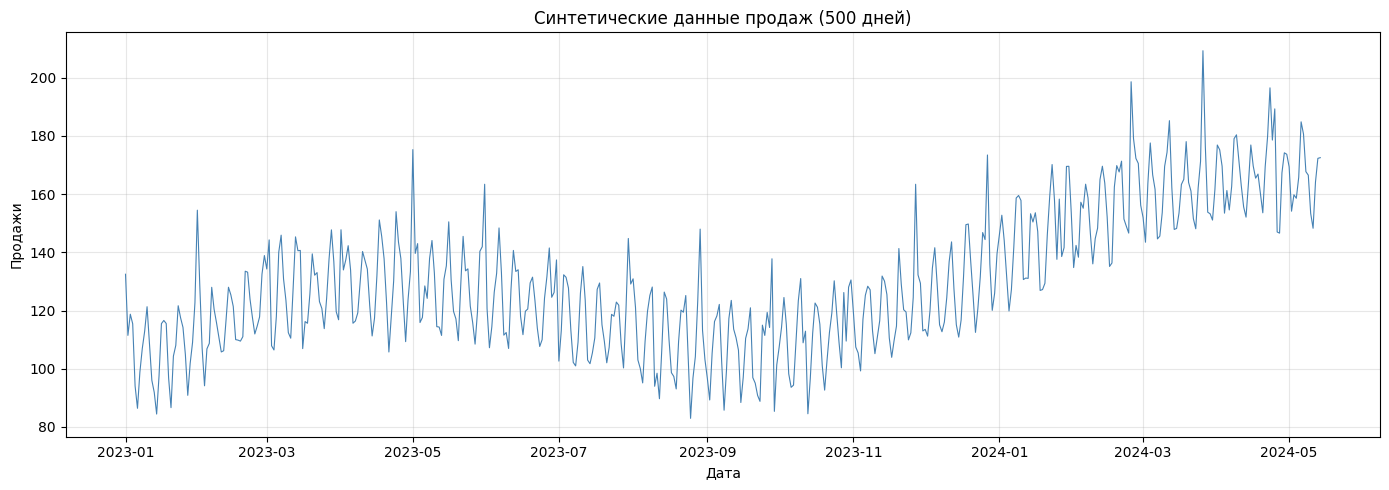

Сгенерировано 500 записей
        date       sales
0 2023-01-01  132.483571
1 2023-01-02  111.480618
2 2023-01-03  118.751194
3 2023-01-04  115.456400
4 2023-01-05   94.097827
5 2023-01-06   86.425695
6 2023-01-07   98.831828
7 2023-01-08  106.942737
8 2023-01-09  112.927279
9 2023-01-10  121.324699


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

days = 500
dates = pd.date_range(start='2023-01-01', periods=days, freq='D')

trend = np.linspace(100, 150, days)

weekly_season = 15 * np.sin(2 * np.pi * np.arange(days) / 7)

yearly_season = 20 * np.sin(2 * np.pi * np.arange(days) / 365)

holiday_spike = np.where(np.arange(days) % 30 == 0, 30, 0)

noise = np.random.normal(0, 5, days)

sales = trend + weekly_season + yearly_season + holiday_spike + noise
sales = np.maximum(sales, 0)

df = pd.DataFrame({'date': dates, 'sales': sales})
df.to_csv('sales_data.csv', index=False)

plt.figure(figsize=(14, 5))
plt.plot(df['date'], df['sales'], linewidth=0.8, color='steelblue')
plt.title('Синтетические данные продаж (500 дней)')
plt.xlabel('Дата')
plt.ylabel('Продажи')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('sales_history.png', dpi=150)
plt.show()

print(f"Сгенерировано {len(df)} записей")
print(df.head(10))

In [ ]:
import numpy as np
import torch
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

# ------------------------------
# 2.1 Нормализация
# ------------------------------
sales = df['sales'].values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0, 1))
sales_scaled = scaler.fit_transform(sales)

print(f"Диапазон после нормализации: [{sales_scaled.min():.3f}, {sales_scaled.max():.3f}]")

# ------------------------------
# 2.2 Функция нарезки окон
# ------------------------------
def create_sequences(data, input_len=14, output_len=7):
    X, y = [], []
    for i in range(len(data) - input_len - output_len):
        X.append(data[i : i + input_len])
        y.append(data[i + input_len : i + input_len + output_len])
    return np.array(X), np.array(y)

INPUT_WINDOW = 14   # по скольким дням предсказываем
OUTPUT_WINDOW = 7   # на сколько дней вперёд

X_all, y_all = create_sequences(sales_scaled, INPUT_WINDOW, OUTPUT_WINDOW)

print(f"Форма X: {X_all.shape}")  # должно быть [samples, 14, 1]
print(f"Форма y: {y_all.shape}")  # должно быть [samples, 7, 1]

# ------------------------------
# 2.3 Разделение train/test (80/20 по времени)
# ------------------------------
split = int(0.8 * len(X_all))
X_train, X_test = X_all[:split], X_all[split:]
y_train, y_test = y_all[:split], y_all[split:]

print(f"Train: {X_train.shape[0]} примеров")
print(f"Test:  {X_test.shape[0]} примеров")

# ------------------------------
# 2.4 Преобразование в тензоры
# ------------------------------
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

# DataLoader для батчевого обучения
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(f"Батчей в train_loader: {len(train_loader)}")

Диапазон после нормализации: [0.000, 1.000]
Форма X: (479, 14, 1)
Форма y: (479, 7, 1)
Train: 383 примеров
Test:  96 примеров
Батчей в train_loader: 12


In [ ]:
from sklearn.metrics import mean_absolute_error

# ------------------------------
# 3. Baseline: "завтра = сегодня"
# ------------------------------
# Берём последний известный день из каждого окна и повторяем его 7 раз
last_day_value = X_test[:, -1, :]              # [96, 1]
baseline_pred = np.repeat(last_day_value, OUTPUT_WINDOW, axis=1)  # [96, 7]

# MAE в нормализованном масштабе
baseline_mae = mean_absolute_error(y_test[:, :, 0], baseline_pred)

# MAE в реальных продажах
baseline_pred_real = scaler.inverse_transform(baseline_pred)
y_test_real = scaler.inverse_transform(y_test[:, :, 0])
baseline_mae_real = mean_absolute_error(y_test_real.flatten(), baseline_pred_real.flatten())

print(f"Baseline MAE (нормализованный): {baseline_mae:.5f}")
print(f"Baseline MAE (в продажах):       {baseline_mae_real:.2f}")

Baseline MAE (нормализованный): 0.11541
Baseline MAE (в продажах):       14.58


In [ ]:
import torch.nn as nn
import torch.optim as optim

# ------------------------------
# 4.1 Архитектура LSTM
# ------------------------------
class SalesLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=7):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                            batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        lstm_out, _ = self.lstm(x)          # [batch, 14, hidden]
        last_hidden = lstm_out[:, -1, :]    # [batch, hidden]
        out = self.fc(last_hidden)          # [batch, 7]
        return out

model = SalesLSTM(input_size=1, hidden_size=64, num_layers=2, output_size=OUTPUT_WINDOW)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)

SalesLSTM(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=7, bias=True)
)


In [ ]:
# ------------------------------
# 4.2 Обучение LSTM
# ------------------------------
epochs = 100
train_losses = []

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)                    # [batch, 7]
        loss = criterion(outputs, batch_y[:, :, 0]) # y: [batch, 7, 1] -> [batch, 7]
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    
    if epoch % 20 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch:3d}/{epochs}  |  Loss: {avg_loss:.6f}")


Epoch   0/100  |  Loss: 0.004657
Epoch  20/100  |  Loss: 0.004627
Epoch  40/100  |  Loss: 0.004582
Epoch  60/100  |  Loss: 0.004514
Epoch  80/100  |  Loss: 0.004517
Epoch  99/100  |  Loss: 0.004501


In [ ]:
# ------------------------------
# 5.1 Прогноз на тесте
# ------------------------------
model.eval()
with torch.no_grad():
    predictions_scaled = model(X_test_t).numpy()  # [96, 7]

# ------------------------------
# 5.2 Обратное масштабирование
# ------------------------------
predictions_real = scaler.inverse_transform(predictions_scaled)
y_test_real = scaler.inverse_transform(y_test[:, :, 0])

# ------------------------------
# 5.3 MAE нейросети
# ------------------------------
nn_mae_real = mean_absolute_error(y_test_real.flatten(), predictions_real.flatten())

print(f"Baseline MAE (повтор):  {baseline_mae_real:.2f}")
print(f"Neural Network MAE:    {nn_mae_real:.2f}")
print(f"Разница:                 {baseline_mae_real - nn_mae_real:.2f}")


Baseline MAE (повтор):  14.58
Neural Network MAE:    8.03
Разница:                 6.55


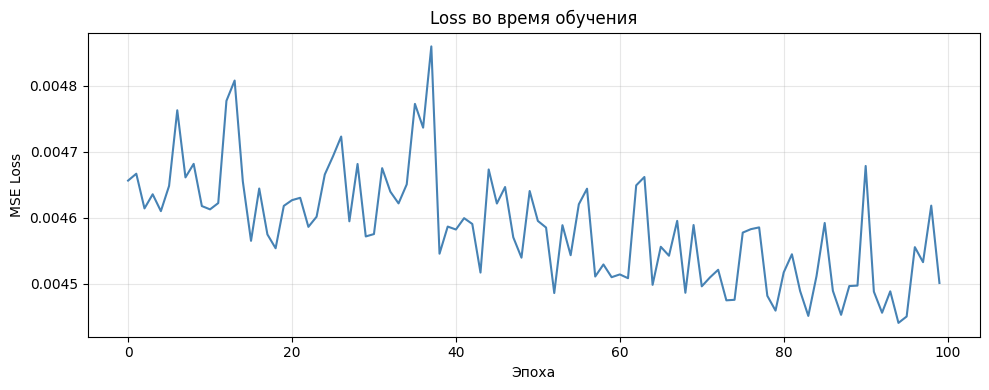

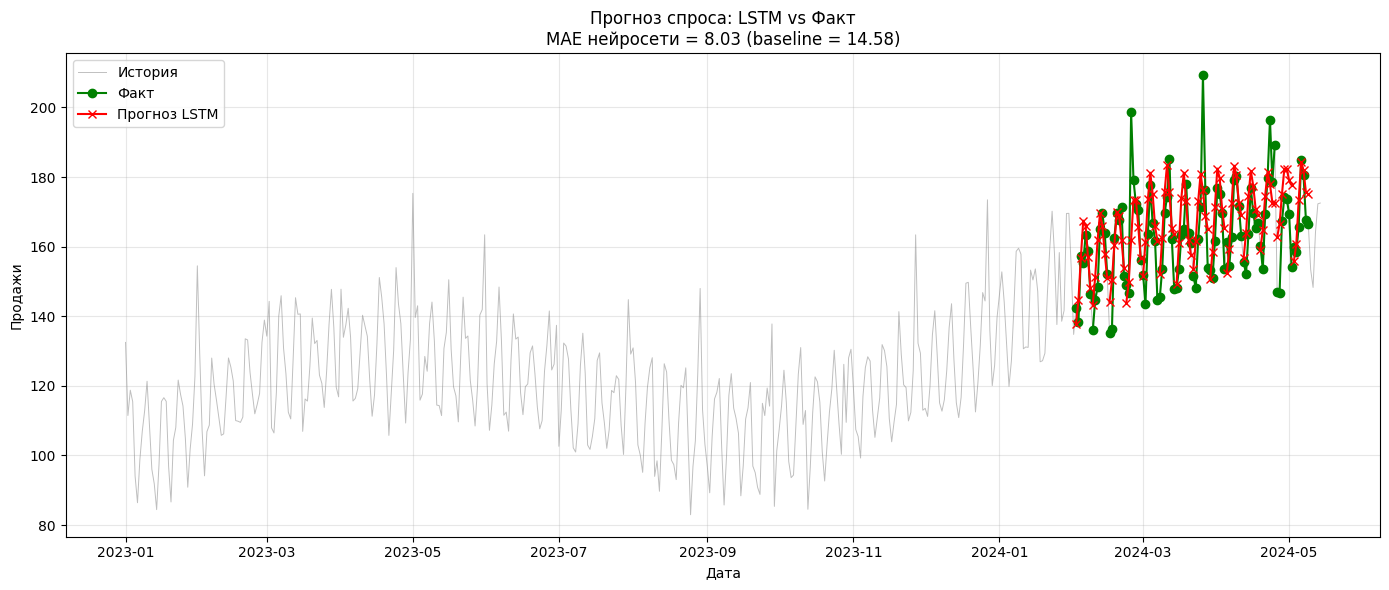

✅ Графики сохранены: training_loss.png, prediction_plot.png


In [ ]:
import matplotlib.pyplot as plt

# ------------------------------
# 6.1 График Loss по эпохам
# ------------------------------
plt.figure(figsize=(10, 4))
plt.plot(train_losses, color='steelblue')
plt.title('Loss во время обучения')
plt.xlabel('Эпоха')
plt.ylabel('MSE Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_loss.png', dpi=150)
plt.show()

# ------------------------------
# 6.2 График "Факт vs Прогноз" на тесте
# ------------------------------
# Соберём реальные даты для тестового участка
test_start_idx = split + INPUT_WINDOW

plt.figure(figsize=(14, 6))

# Фоном — исторические продажи
plt.plot(df['date'], df['sales'], linewidth=0.7, alpha=0.5, color='gray', label='История')

# Последние 90 дней тестового периода
for i in range(0, len(predictions_real), 7):
    idx = test_start_idx + i
    if idx + 7 > len(df):
        break
    dates = df['date'].iloc[idx : idx + 7]
    plt.plot(dates, y_test_real[i], marker='o', color='green', linewidth=1.5, 
             label='Факт' if i == 0 else '')
    plt.plot(dates, predictions_real[i], marker='x', color='red', linewidth=1.5, 
             label='Прогноз LSTM' if i == 0 else '')

plt.title(f'Прогноз спроса: LSTM vs Факт\nMAE нейросети = {nn_mae_real:.2f} (baseline = {baseline_mae_real:.2f})')
plt.xlabel('Дата')
plt.ylabel('Продажи')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('prediction_plot.png', dpi=150)
plt.show()
